# Detecting housing bubbles on the danish housing market

This project is trying to detect if there are any explosive behaviour on the danish housing market, from the first quarter of 1998 to the fourth quarter of 2023. 

The idea of the project is to test the real danish housing prices for unite roots. The procedure used is the BSADF test, wich is introduced in Philips (2011). The difference from the classical is there in a BSADF test is a flexible window width. 

In [1]:
#importing packages
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

The following code shows that the last collom of the variable has no values, and therefore we want to delete it.

This code first displays the data, in which we can see that row 103 is missing some values. The last part of the code deletes the unwanted row. The new dataset can be seen in the output. 

In [2]:
# Read the Excel file into a DataFrame
df = pd.read_excel("Huspris_kvartal.xlsx")

# Display the original DataFrame
print("Original DataFrame:")
print(df)

# Drop the last row
df = df.drop(df.index[-1])

# Display the modified DataFrame without the last row
print("\nDataFrame after deleting the last row:")
print(df)



Original DataFrame:
     Period  EF_Hele_landet  EF_Region_H  EL_Hele_landet  EL_Region_H  \
0    1998q1           870.0       1290.0           614.0        657.0   
1    1998q2           900.0       1358.0           634.0        676.0   
2    1998q3           869.0       1315.0           626.0        663.0   
3    1998q4           897.0       1400.0           654.0        703.0   
4    1999q1           933.0       1433.0           698.0        765.0   
..      ...             ...          ...             ...          ...   
99   2022q4          2390.0       4555.0          2739.0       3318.0   
100  2023q1          2526.0       4467.0          2754.0       3245.0   
101  2023q2          2621.0       4646.0          2943.0       3469.0   
102  2023q3          2663.0       4724.0          2983.0       3557.0   
103  2023q4             NaN          NaN             NaN          NaN   

        Rente     CPI  Inflation     RHP_EFHL     RHP_EFRH     RHP_ELHL  \
0    6.783077   71.67     0.

In this section we load our data and mark that the data is on a quarterly basis.

In [3]:
file_path = 'Huspris_kvartal.xlsx'
df = pd.read_excel(file_path)

df['Year'] = df['Period'].str.extract('(\d{4})')
df['Quarter'] = df['Period'].str.extract('q(\d)')

# Convert to datetime and set as index
df['Period'] = pd.to_datetime(df['Year'] + df['Quarter'], format='%Y%m')
df.set_index('Period', inplace=True)

In the next section the code plots the real house prices for single family houses in the region of Copenhagen.

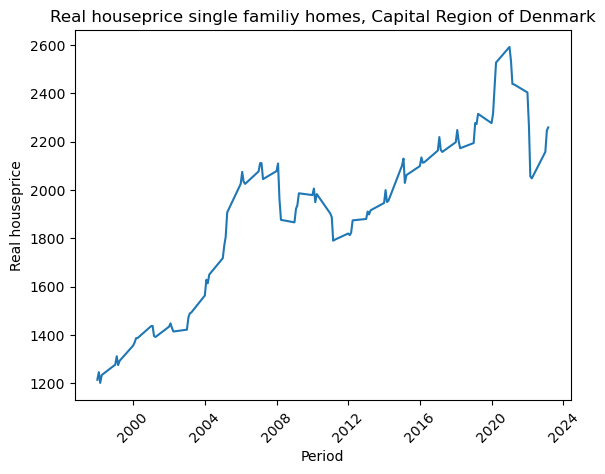

In [4]:
# Plotting the values of the column RHP_EFHL
price = df['RHP_EFHL']
plt.plot(df.index, price)
plt.title('Real houseprice single familiy homes, Capital Region of Denmark') 
plt.xlabel('Period')
plt.ylabel('Real houseprice')
plt.xticks(rotation=45)
plt.show()

# Interpretation of our data
Looking at the raw data from Copenhagen, we see an immediate explovsive growth in the house prices in the period of 2005-2008 and again in 2020-2021. To check wether this result is correct, we will now conduct a BSADF test to check if our time series has unite roots.

DatetimeIndex(['2004-02-01', '2004-03-01', '2004-04-01', '2005-01-01',
               '2005-02-01', '2005-03-01', '2005-04-01', '2006-01-01',
               '2006-02-01', '2006-03-01', '2006-04-01', '2014-03-01',
               '2020-04-01', '2021-01-01', '2021-02-01', '2022-03-01',
               '2022-04-01'],
              dtype='datetime64[ns]', name='Period', freq=None)


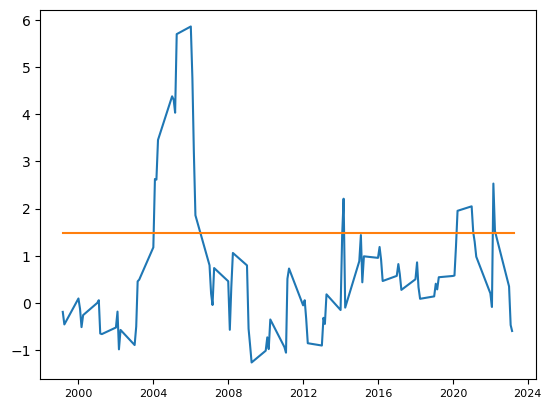

In [5]:
#this is a bubble detecting algorithm developed by Phillips and Yu (2011) and Phillips et al. (2015) 
#it is based on the augmented Dickey-Fuller test and is used to detect bubbles in financial data.

# Generate price variable
prices = df['RHP_EFRH']

# Inputting the parameters
r0 = int(len(prices) * 0.05)
adf_lags = 1
crit = 1.49
#transforming data
log_prices = np.array(np.log(prices))
delta_log_prices = log_prices[1:] - log_prices[:-1]
n = len(delta_log_prices)
BSADF = np.array([])
#calculating ADF stats
for r2 in range(r0,n):
    ADFS = np.array([])
    for r1 in range(0,r2-r0+1):
        X0 = log_prices[r1:r2+1]
        X = pd.DataFrame()
        X[0] = X0
        for j in range(1,adf_lags+1):
            X[j] = np.append(np.zeros(j),delta_log_prices[r1:r2+1-j])
        X = np.array(X)
        Y = delta_log_prices[r1:r2+1]
        reg = sm.OLS(Y,sm.add_constant(X))
        res = reg.fit()
        ADFS = np.append(ADFS, res.params[1]/res.bse[1])
    BSADF = np.append(BSADF, max(ADFS))
#visualising the results
plt.rc('xtick',labelsize = 8)
plt.plot(prices.index[r0+1:],BSADF)
plt.plot(prices.index[r0+1:],np.ones(len(BSADF))*crit)
#printing dates when bubbles were detected
print(prices.index[r0+1:][BSADF > crit])

# Interpretation of our data
Looking at the output the date TimeIndex is where the t-test value is above the 5% critical value, and therefore could be characterized as a housing bubble. We notice that the bubble of the financiel crises of 2008 is marked, also with a build up starting in the period of 2005. A more interesting result is, that there is also a bubble after the outbreak of Covid-19. The results needs to be taken with a grain of salt, as this is only the prices and therefore without any fundamentel factors taken into account; such as the interest rate level or the disposabel income.

# Modelling volatility


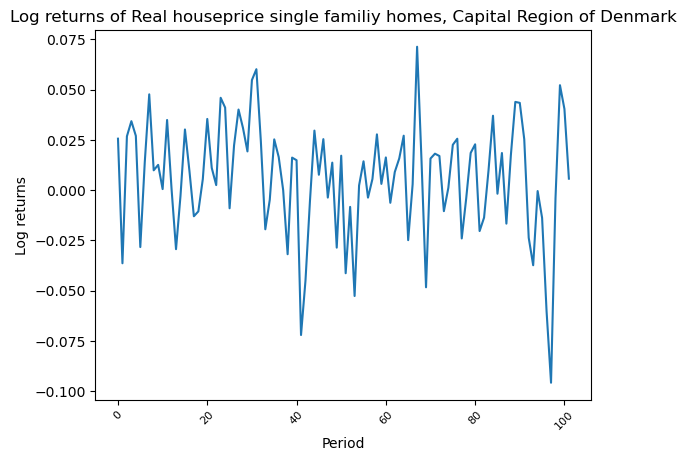

Iteration:      1,   Func. Count:      6,   Neg. LLF: 3926681.659348047
Iteration:      2,   Func. Count:     16,   Neg. LLF: 640.263896486822
Iteration:      3,   Func. Count:     23,   Neg. LLF: -210.82715661158622
Iteration:      4,   Func. Count:     30,   Neg. LLF: -222.15018972778452
Iteration:      5,   Func. Count:     36,   Neg. LLF: -206.98551069298998
Iteration:      6,   Func. Count:     43,   Neg. LLF: -222.64985901554567
Iteration:      7,   Func. Count:     50,   Neg. LLF: -222.74035294345342
Iteration:      8,   Func. Count:     55,   Neg. LLF: -222.74038157799822
Iteration:      9,   Func. Count:     59,   Neg. LLF: -222.74038157798174
Optimization terminated successfully    (Exit mode 0)
            Current function value: -222.74038157799822
            Iterations: 9
            Function evaluations: 59
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:               RHP_EFHL   R-squared: 

/var/folders/gk/26n2_j3x5vv_n8bzrm4z1zp40000gn/T/ipykernel_58859/1753265942.py:28: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  log_returns = prices.pct_change().dropna()
/Users/alexandereinar/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.000793. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [6]:
import arch
from arch import arch_model

file_path = 'Huspris_kvartal.xlsx'
df = pd.read_excel(file_path)
price= df['RHP_EFHL']
log_prices = np.array(np.log(price))
delta_log_prices = log_prices[1:] - log_prices[:-1]
plt.plot(delta_log_prices)
plt.title('Log returns of Real houseprice single familiy homes, Capital Region of Denmark')
plt.xlabel('Period')
plt.ylabel('Log returns')
plt.xticks(rotation=45)
plt.show()

# Extract year and quarter separately
df['Year'] = df['Period'].str.extract('(\d{4})')
df['Quarter'] = df['Period'].str.extract('q(\d)')

# Convert to datetime and set as index
df['Period'] = pd.to_datetime(df['Year'] + df['Quarter'], format='%Y%m')
df.set_index('Period', inplace=True)

# Generate price variable
prices = df['RHP_EFHL']

# Compute log returns
log_returns = prices.pct_change().dropna()

# Build GARCH(1,1) model
garch_model = arch_model(log_returns, vol='Garch', p=1, q=1)

# Fit the model
garch_result = garch_model.fit()

# Print model summary
print(garch_result.summary())


# Interpretation of our data
We can see by the log diferences, that there is a changing volatility, and therefore we suggets that we could instead use an ARCH model.  We move on to model the volatility of the hhouseprice growth rates. We do the by transforming our dating, hence taking log differences. We plot the growth rates in the graph below. We visual inspection we see that the variance seems to be changing acroos our sample which is we then seek to model by a GARCH model. The estimation results of our GARCH(1,1) can be found seen below. 